In [82]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
X = rf_preprocessor.group_and_pad(rf_preprocessor.sensor_df, group_col="Experiment_ID")[50:51,:,:]
Y = rf_preprocessor.group_and_pad(rf_preprocessor.target_df, group_col="Experiment_ID")[50:51,:-1,1:]
#X_rf, Y_rf = rf_preprocessor.prepare_rf_data(X, Y)

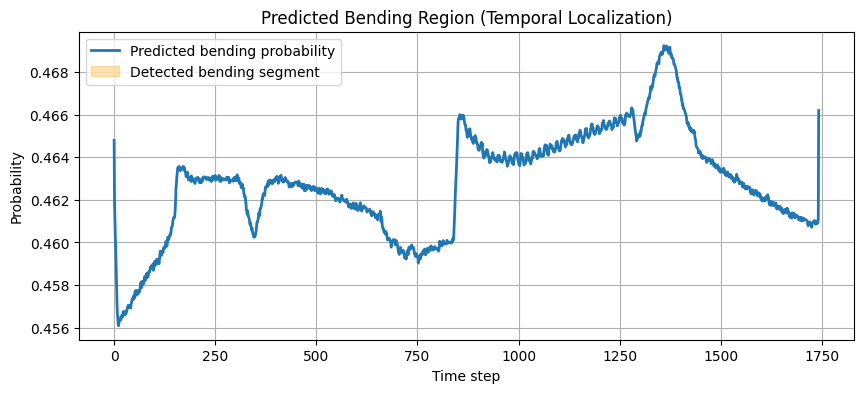

In [83]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Example signal
# -----------------------
# X.shape = (seq_len, n_features)
_, seq_len, n_features= X.shape

# Convert to torch tensor and add batch dimension
x_tensor = torch.tensor(X, dtype=torch.float32)  # shape: (1, seq_len, n_features)

# -----------------------
# Define model
# -----------------------
class TemporalLocalizationNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.loc_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h, _ = self.encoder(x)
        scores = torch.sigmoid(self.loc_head(h)).squeeze(-1)
        return scores  # (batch, seq_len)

# -----------------------
# Run the model
# -----------------------
model = TemporalLocalizationNet(input_dim=n_features)
scores = model(x_tensor).detach().numpy()[0]  # take first (and only) batch

# -----------------------
# Threshold and visualize
# -----------------------
threshold = 0.5
mask = scores > threshold
t = np.arange(seq_len)

plt.figure(figsize=(10, 4))
plt.plot(t, scores, label='Predicted bending probability', lw=2)
plt.fill_between(t, 0, 1, where=mask, color='orange', alpha=0.3, label='Detected bending segment')
plt.xlabel("Time step")
plt.ylabel("Probability")
plt.title("Predicted Bending Region (Temporal Localization)")
plt.legend()
plt.grid(True)
plt.show()


Detected change points: [145, 330, 425, 540, 700, 845, 940, 1125, 1310, 1410, 1743]
Most important timestamp: 304 (sample index)
Corresponding time ≈ 30.4 seconds


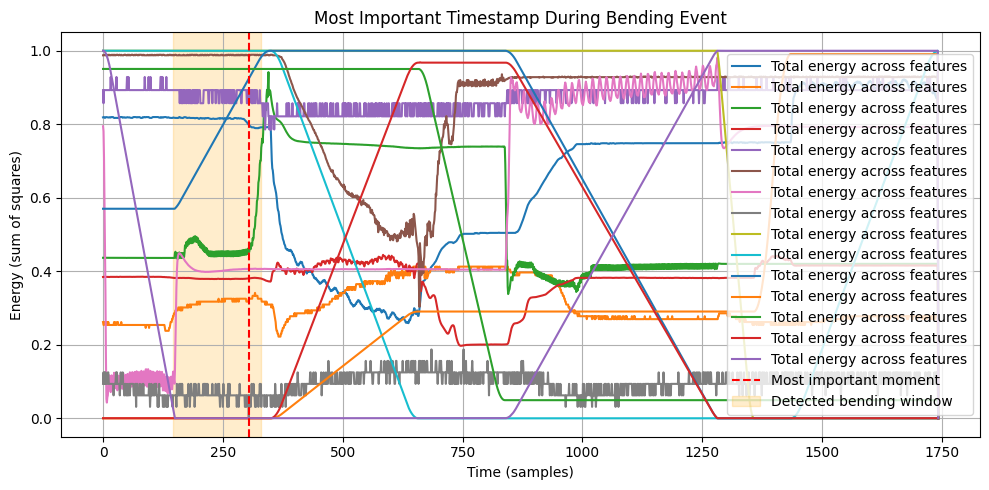

In [86]:
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# -----------------------
# Simulate multivariate bending data
# -----------------------
X = X.squeeze()

# Normalize for fair feature weighting
X = StandardScaler().fit_transform(X)

# -----------------------
# Detect change points
# -----------------------
model = "rbf"
algo = rpt.Pelt(model=model).fit(X)
result = algo.predict(pen=10)

print("Detected change points:", result)

# -----------------------
# Find the main event window (assume 2 change points)
# -----------------------
if len(result) >= 2:
    start, end = result[0], result[1]
else:
    # fallback: if only one breakpoint found
    start, end = result[0] - 100, result[0] + 100

# -----------------------
# Compute importance score (e.g. energy across all features)
# -----------------------
energy = np.sum(X[start:end] ** 2, axis=1)
peak_idx = np.argmax(energy)
important_timestamp = start + peak_idx

print(f"Most important timestamp: {important_timestamp} (sample index)")
print(f"Corresponding time ≈ {important_timestamp/10:.1f} seconds")

# -----------------------
# Visualization
# -----------------------
plt.figure(figsize=(10, 5))
plt.plot(signal, label='Total energy across features')
plt.axvline(important_timestamp, color='r', linestyle='--', label='Most important moment')
plt.axvspan(start, end, color='orange', alpha=0.2, label='Detected bending window')
plt.xlabel("Time (samples)")
plt.ylabel("Energy (sum of squares)")
plt.legend()
plt.title("Most Important Timestamp During Bending Event")
plt.grid(True)
plt.tight_layout()
plt.show()
